In [2]:
import sys
import os
import pickle

# Добавляем родительскую директорию в путь
sys.path.insert(0, os.path.abspath('..'))

from typing_extensions import TypedDict
from typing import Annotated, Any
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage
from IPython.display import Image, display

# Теперь можно импортировать как пакет
from backend.models.schemas import (
    GenerateRequest, GenerateResponse,
    SolveRequest, SolveResponse, AgentResult
)

from backend.agents.generator import GeneratorAgent
from backend.agents.solver import SolverAgent
from backend.agents.reviewer import ReviewerAgent

In [2]:
with open("../static_dataset/list_dict_with_tasks.pkl", "rb") as file:
    list_json = pickle.load(file)

In [3]:
curr_task = list_json[47]

curr_task['problem'], curr_task['answer'],

('Вадим и Лёша спускались с горы. Вадим шёл пешком, а Лёша съезжал на лыжах в семь раз быстрее Вадима. На полпути Лёша упал, сломал лыжи и ногу и пошёл в два раза медленней Вадима. Кто первым спустится с горы?',
 'Вадим')

# Прогоняем Agent-Solver на одном примере

In [4]:
solver = SolverAgent()

/home/tas/.cache/pypoetry/virtualenvs/ai-mas-hse-project-VtkJAIkS-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
solver_result = solver.solve(curr_task['problem'])

In [28]:
solver_result.keys()

dict_keys(['full_response', 'answer'])

In [29]:
solver_result

{'full_response': 'РЕШЕНИЕ:  \n1. Пусть скорость Вадима \\( v \\). Тогда скорость Лёши на лыжах \\( 7v \\), а после падения — \\( \\frac{v}{2} \\).  \n2. Пусть весь путь с горы равен \\( S \\). Тогда полпути — \\( \\frac{S}{2} \\).  \n3. Время Вадима на весь путь: \\( t_1 = \\frac{S}{v} \\).  \n4. Время Лёши:  \n   - Первую половину: \\( t_{2a} = \\frac{S/2}{7v} = \\frac{S}{14v} \\).  \n   - Вторую половину: \\( t_{2b} = \\frac{S/2}{v/2} = \\frac{S}{v} \\).  \n   - Общее время Лёши: \\( t_2 = \\frac{S}{14v} + \\frac{S}{v} = \\frac{S}{14v} + \\frac{14S}{14v} = \\frac{15S}{14v} \\).  \n5. Сравним \\( t_1 = \\frac{S}{v} = \\frac{14S}{14v} \\) и \\( t_2 = \\frac{15S}{14v} \\).  \n   Так как \\( \\frac{14S}{14v} < \\frac{15S}{14v} \\), то \\( t_1 < t_2 \\).  \n6. Значит, Вадим спустится первым.  \n\nОТВЕТ: Вадим',
 'answer': 'Вадим'}

In [33]:
print(solver_result['full_response'])

РЕШЕНИЕ:  
1. Пусть скорость Вадима \( v \). Тогда скорость Лёши на лыжах \( 7v \), а после падения — \( \frac{v}{2} \).  
2. Пусть весь путь с горы равен \( S \). Тогда полпути — \( \frac{S}{2} \).  
3. Время Вадима на весь путь: \( t_1 = \frac{S}{v} \).  
4. Время Лёши:  
   - Первую половину: \( t_{2a} = \frac{S/2}{7v} = \frac{S}{14v} \).  
   - Вторую половину: \( t_{2b} = \frac{S/2}{v/2} = \frac{S}{v} \).  
   - Общее время Лёши: \( t_2 = \frac{S}{14v} + \frac{S}{v} = \frac{S}{14v} + \frac{14S}{14v} = \frac{15S}{14v} \).  
5. Сравним \( t_1 = \frac{S}{v} = \frac{14S}{14v} \) и \( t_2 = \frac{15S}{14v} \).  
   Так как \( \frac{14S}{14v} < \frac{15S}{14v} \), то \( t_1 < t_2 \).  
6. Значит, Вадим спустится первым.  

ОТВЕТ: Вадим


In [ ]:
static_result = "РЕШЕНИЕ:  \n1. Пусть скорость Вадима \\( v \\). Тогда скорость Лёши на лыжах \\( 7v \\), а после падения — \\( \\frac{v}{2} \\).  \n2. Пусть весь путь с горы равен \\( S \\). Тогда полпути — \\( \\frac{S}{} \\).  \n3. Время Вадима на весь путь: \\( t_1 = \\frac{S}{v} \\).  \n4. Время Лёши:  \n   - Первую половину: \\( t_{2a} = \\frac{S/2}{7v} = \\frac{S}{14v} \\).  \n   - Вторую половину: \\( t_{2b} = \\frac{S/2}{v/2} = \\frac{S}{v} \\).  \n   - Общее время Лёши: \\( t_2 = \\frac{S}{14v} + \\frac{S}{v} = \\frac{S}{14v} + \\frac{14S}{14v} = \\frac{15S}{14v} \\).  \n5. Сравним \\( t_1 = \\frac{S}{v} = \\frac{14S}{14v} \\) и \\( t_2 = \\frac{15S}{14v} \\).  \n   Так как \\( \\frac{14S}{14v} < \\frac{15S}{14v} \\), то \\( t_1 < t_2 \\).  \n6. Значит, Вадим спустится первым.  \n\nОТВЕТ: Вадим"

In [9]:
static_result_wrong = "РЕШЕНИЕ:  \n1. Пусть скорость Леши \\( v \\). Тогда скорость Вадима на лыжах \\( 4v \\), а после падения — \\( \\frac{v}{0} \\).  \n2. Пусть весь путь с горы равен \\( S \\). Тогда полпути — \\( \\frac{S}{} \\).  \n3. Время Вадима на весь путь: \\( t_1 = \\frac{S}{v} \\).  \n4. Время Лёши:  \n   - Первую половину: \\( t_{2a} = \\frac{S/2}{7v} = \\frac{S}{14v} \\).  \n   - Вторую половину: \\( t_{2b} = \\frac{S/5}{v/2} = \\frac{S}{v} \\).  \n   - Общее время Лёши: \\( t_2 = \\frac{S}{14v} + \\frac{S}{v} = \\frac{S}{14v} + \\frac{14S}{14v} = \\frac{15S}{14v} \\).  \n5. Сравним \\( t_1 = \\frac{S}{v} = \\frac{14S}{14v} \\) и \\( t_2 = \\frac{15S}{14v} \\).  \n   Так как \\( \\frac{14S}{14v} < \\frac{15S}{14v} \\), то \\( t_1 < t_2 \\).  \n6. Значит, Вадим спустится первым.  \n\nОТВЕТ: Вадим"

# Прогоняем Agent-Solver на одном примере

In [10]:
reviewer = ReviewerAgent()

In [11]:
# reviewer_result = reviewer.review(
#     solver_answer=f"Решение и ответ пользователя: {solver_result['full_response']}",
#     ground_truth=curr_task['answer']
#     )

In [12]:
reviewer_result = reviewer.review(
    solver_answer=f"Решение и ответ пользователя: {static_result_wrong}", # Поставь static_result или static_result_wrong в зависимости от теста
    ground_truth=curr_task['answer']
    )

In [13]:
reviewer_result

{'full_response': 'ВЕРДИКТ: ОШИБКА В РЕШЕНИИ  \nАНАЛИЗ ОТВЕТА: правильный, совпал с правильным ответом "Вадим".  \nАНАЛИЗ РЕШЕНИЯ: Ученик допустил несколько грубых ошибок в условиях и подстановках. Скорость Вадима на лыжах указана как \\(4v\\), но в условии задачи она равна \\(7v\\) (в 7 раз больше скорости Лёши). Скорость Вадима после падения записана как \\(v/0\\) (деление на ноль, что бессмысленно), хотя по условию она в 2 раза меньше скорости Лёши, то есть \\(v/2\\). Также в формуле полпути пропущено число 2 (\\(S/2\\)). Несмотря на это, в промежуточных вычислениях ученик неожиданно использовал правильные значения: скорость Вадима на лыжах \\(7v\\) и после падения \\(v/2\\), что привело к верному сравнению времён. Однако исходные обозначения противоречат дальнейшим шагам.  \nРЕКОМЕНДАЦИЯ: Внимательно записывай условия задачи. Проверь, чтобы все обозначения скоростей соответствовали условию (Вадим на лыжах — \\(7v\\), после падения — \\(v/2\\)) и избегай математических некорректност

# Расчет метрик

In [3]:
with open("../static_dataset/list_dict_with_tasks.pkl", "rb") as file:
    list_json = pickle.load(file)

In [ ]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    topic: str
    problem: str
    ground_truth: str
    user_solution: str
    solver_answer: str
    solver_full: str
    review_verdict: str
    review_is_correct: bool
    review_full_response: str
    review_answer_analysis: str
    review_solution_analysis: str
    review_recommendation: str

In [5]:
def _solve_node(state: AgentState) -> dict:
    result = ag_solver.solve(state["problem"])
    return {
        "solver_answer": result["solver_answer"],
        "solver_full": result["solver_full"],
        "messages": []
    }

def _review_node(state: AgentState) -> dict:
    result = ag_reviewer.review(state['solver_full'], state['ground_truth'])
    return {
        "review_verdict": result["verdict"],
        "review_is_correct": result["is_correct"],
        "review_full_response": result["full_response"],
        "review_answer_analysis": result["answer_analysis"],
        "review_solution_analysis": result["solution_analysis"],
        "review_recommendation": result["recommendation"],
        "messages": []
    }

In [6]:
ag_solver = SolverAgent()
ag_reviewer = ReviewerAgent()

# Строим граф
builder = StateGraph(AgentState)

builder.add_node("solve", _solve_node)
builder.add_node("review", _review_node)

# Полный pipeline: генерация -> решение -> проверка пользовательского ответа
builder.set_entry_point("solve")
builder.add_edge("solve", "review")
builder.add_edge("review", END)

graph = builder.compile()

/home/tas/.cache/pypoetry/virtualenvs/ai-mas-hse-project-VtkJAIkS-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


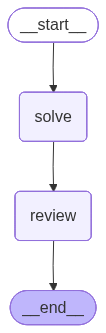

In [7]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
list_json[:2], len(list_json)

([{'id': 115968,
   'topic': 'Алгебра и арифметика',
   'subtopic': 'Исследование квадратного трехчлена',
   'complexity_level': '2+',
   'problem': 'Известно, что разность кубов корней квадратного уравнения ax ² + bx + c = 0 равна 2011. Сколько корней имеет уравнение ax ² + 2 bx + 4 c = 0?',
   'solution': 'Из условия следует, что первое уравнение имеет два корня. Следовательно, его дискриминант D = b ² – 4 ac &gt; 0. Упрощенный дискриминант второго уравнения также равен b ² – 4 ac , значит, оно также имеет два корня.',
   'answer': 'Два корня'},
  {'id': 64824,
   'topic': 'Алгебра и арифметика',
   'subtopic': 'Текстовые задачи (прочее)',
   'complexity_level': '3',
   'problem': 'Три пирата нашли клад, состоящий из 240 золотых слитков общей стоимостью 360 долларов. Стоимость каждого слитка известна и выражается целым числом долларов. Может ли оказаться так, что добычу нельзя разделить между пиратами поровну, не переплавляя слитки?',
   'solution': 'Пусть один из слитков стоит 121 д

In [ ]:
# # Собираем результаты LLM по всем задачам

# tasks_results = []

# for i_task_id_in_list, i_task in enumerate(list_json[:]):
#     print(i_task_id_in_list)
#     # Подготавливаем начальное состояние
#     initial_state = {
#         "messages": [],
#         "topic": "",
#         "problem": i_task['problem'],
#         "ground_truth": i_task['answer'],
#         "user_solution": "",
#         "solver_answer": "",
#         "solver_full": "",
#         "review_verdict": "",
#         "review_is_correct": "",
#         "review_full_response": "",
#         "review_answer_analysis": "",
#         "review_solution_analysis": "",
#         "review_recommendation": ""
#     }

#     result = graph.invoke(initial_state)
#     result['index_of_task'] = i_task_id_in_list

#     tasks_results.append(result)

# # Сохраняем результаты запросов к LLM в .pkl формат
# with open("tasks_result_deepseek_23_02_2026.pkl", "wb") as file:
#     pickle.dump(tasks_results, file)

In [15]:
with open('tasks_result_deepseek_23_02_2026.pkl', 'rb') as file:
    tasks_results = pickle.load(file)

In [16]:
# Считаем SR

cnt_all = len(tasks_results)
cnt_success = 0

for i_task in tasks_results:
    if i_task['review_verdict'] == "ВЕРНО":
        cnt_success +=1

success_rate = round(cnt_success / cnt_all, 2)

print(f"Всего задач: {cnt_all}")
print(f"Решены ассистентом верно: {cnt_success}")
print(f"Success Rate: {success_rate}")

Всего задач: 147
Решены ассистентом верно: 134
Success Rate: 0.91
